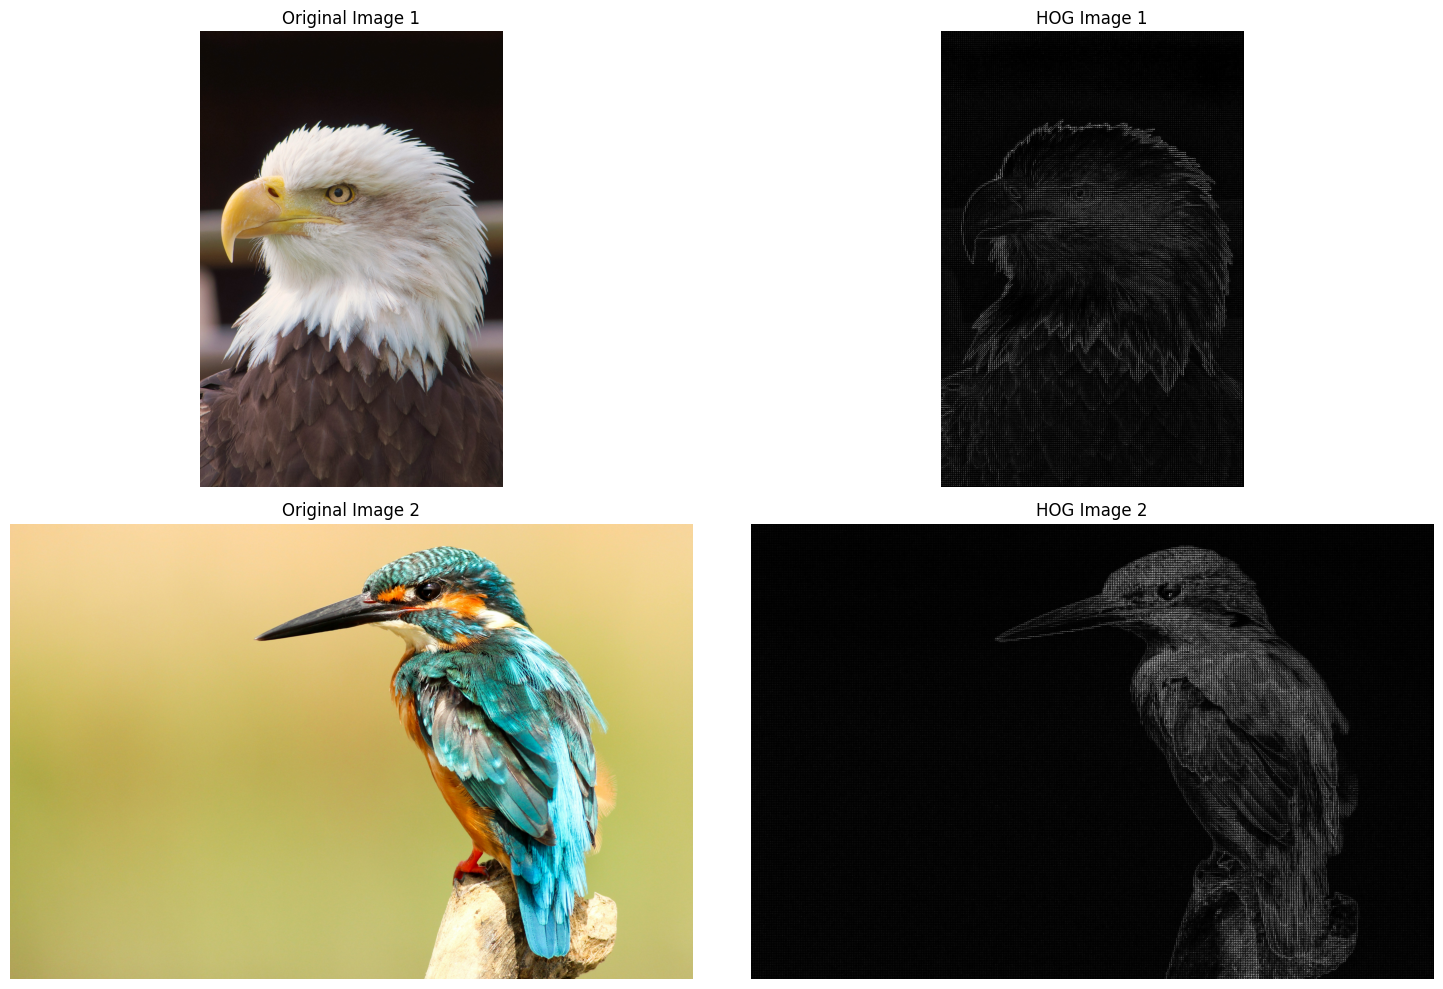

Image 1 HOG feature length: 13023750
Image 2 HOG feature length: 39055500


In [8]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

# List of image paths
image_paths = [
    "/content/eagle.jpg",
    "/content/bird.jpg"
]

hog_features_list = []

plt.figure(figsize=(15, 5 * len(image_paths)))

for i, path in enumerate(image_paths):
    image = cv2.imread(path)

    if image is None:
        print(f"Image not found: {path}")
        continue

    # Convert BGR → RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # HOG extraction
    features, hog_image = hog(
        gray,
        orientations=15,
        pixels_per_cell=(10, 10),
        cells_per_block=(5, 5),
        block_norm='L2-Hys',
        visualize=True
    )

    hog_features_list.append(features)

    # Rescale for visualization
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    # Display original
    plt.subplot(len(image_paths), 2, 2*i + 1)
    plt.imshow(image_rgb)
    plt.title(f"Original Image {i+1}")
    plt.axis("off")

    # Display HOG
    plt.subplot(len(image_paths), 2, 2*i + 2)
    plt.imshow(hog_image_rescaled, cmap='gray')
    plt.title(f"HOG Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Print feature vector sizes
for i, features in enumerate(hog_features_list):
    print(f"Image {i+1} HOG feature length: {len(features)}")
